# 02b — Vérification visuelle des crops manuels

Trace le **sacrum Z brut (400 Hz)** des essais avec un `crop_end_s` proposé.

**Objectif** : valider visuellement la valeur de crop_end_s avant le batch.

- Ligne **rouge** = `crop_end_s` proposé
- Ligne **bleue pointillée** = `TRIM_START_S = 60s` (uniforme tous essais)
- La zone APRÈS la ligne rouge doit montrer un signal aberrant (plat, bruit, etc.)
- Si la zone AVANT la ligne rouge est aussi affectée, le crop doit remonter
- Si la zone APRÈS la ligne rouge a encore du signal propre, le crop peut descendre

In [1]:
from resilience import paths, participants, config
from resilience.io import loader
from resilience.processing.preprocess import compute_barycenter
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Liste des crops à vérifier

Basés sur les incidents techniques du CRF (capteurs dos éteints en fin de session).

In [2]:
# (participant, condition, crop_end_s proposé, raison)
CROPS_TO_CHECK = [
    ('001CrMa', 'beatmove_adaptatif',  360, "capteurs dos ~3/4 session"),
    ('002CrPa', 'tempo_random',        450, "perte 30 dernières s dos"),
    ('003BrLu', 'tempo_random',        440, "Dos éteints ~40s avant fin"),
    ('004CaGe', 'silence',             420, "dos éteint 1min de la fin"),
    ('005DeJe', 'silence',             450, "Dos OUT 30 dernières s"),
    ('005DeJe', 'tempo_random',        450, "Dos OUT 30 dernières s"),
    ('006MoCa', 'silence',             420, "Dos éteint ~1min de la fin"),
    ('006MoCa', 'tempo_random',        307, "Dos OUT à 307s (5min7s)"),
    ('007MoMa', 'beatmove_adaptatif',  420, "Dos éteint ~1min de la fin"),
    ('007MoMa', 'tempo_random',        380, "Dos OUT à 380s (6min20s)"),
    ('008RiMo', 'silence',             360, "Dos éteint 2min de la fin"),
    ('008RiMo', 'beatmove_adaptatif',  450, "Dos éteint vers la fin"),
    ('010DeYv', 'tempo_random',        420, "Dos éteint <1min avant fin"),
]

print(f"Total : {len(CROPS_TO_CHECK)} crops à vérifier")

Total : 13 crops à vérifier


## Tracé des signaux

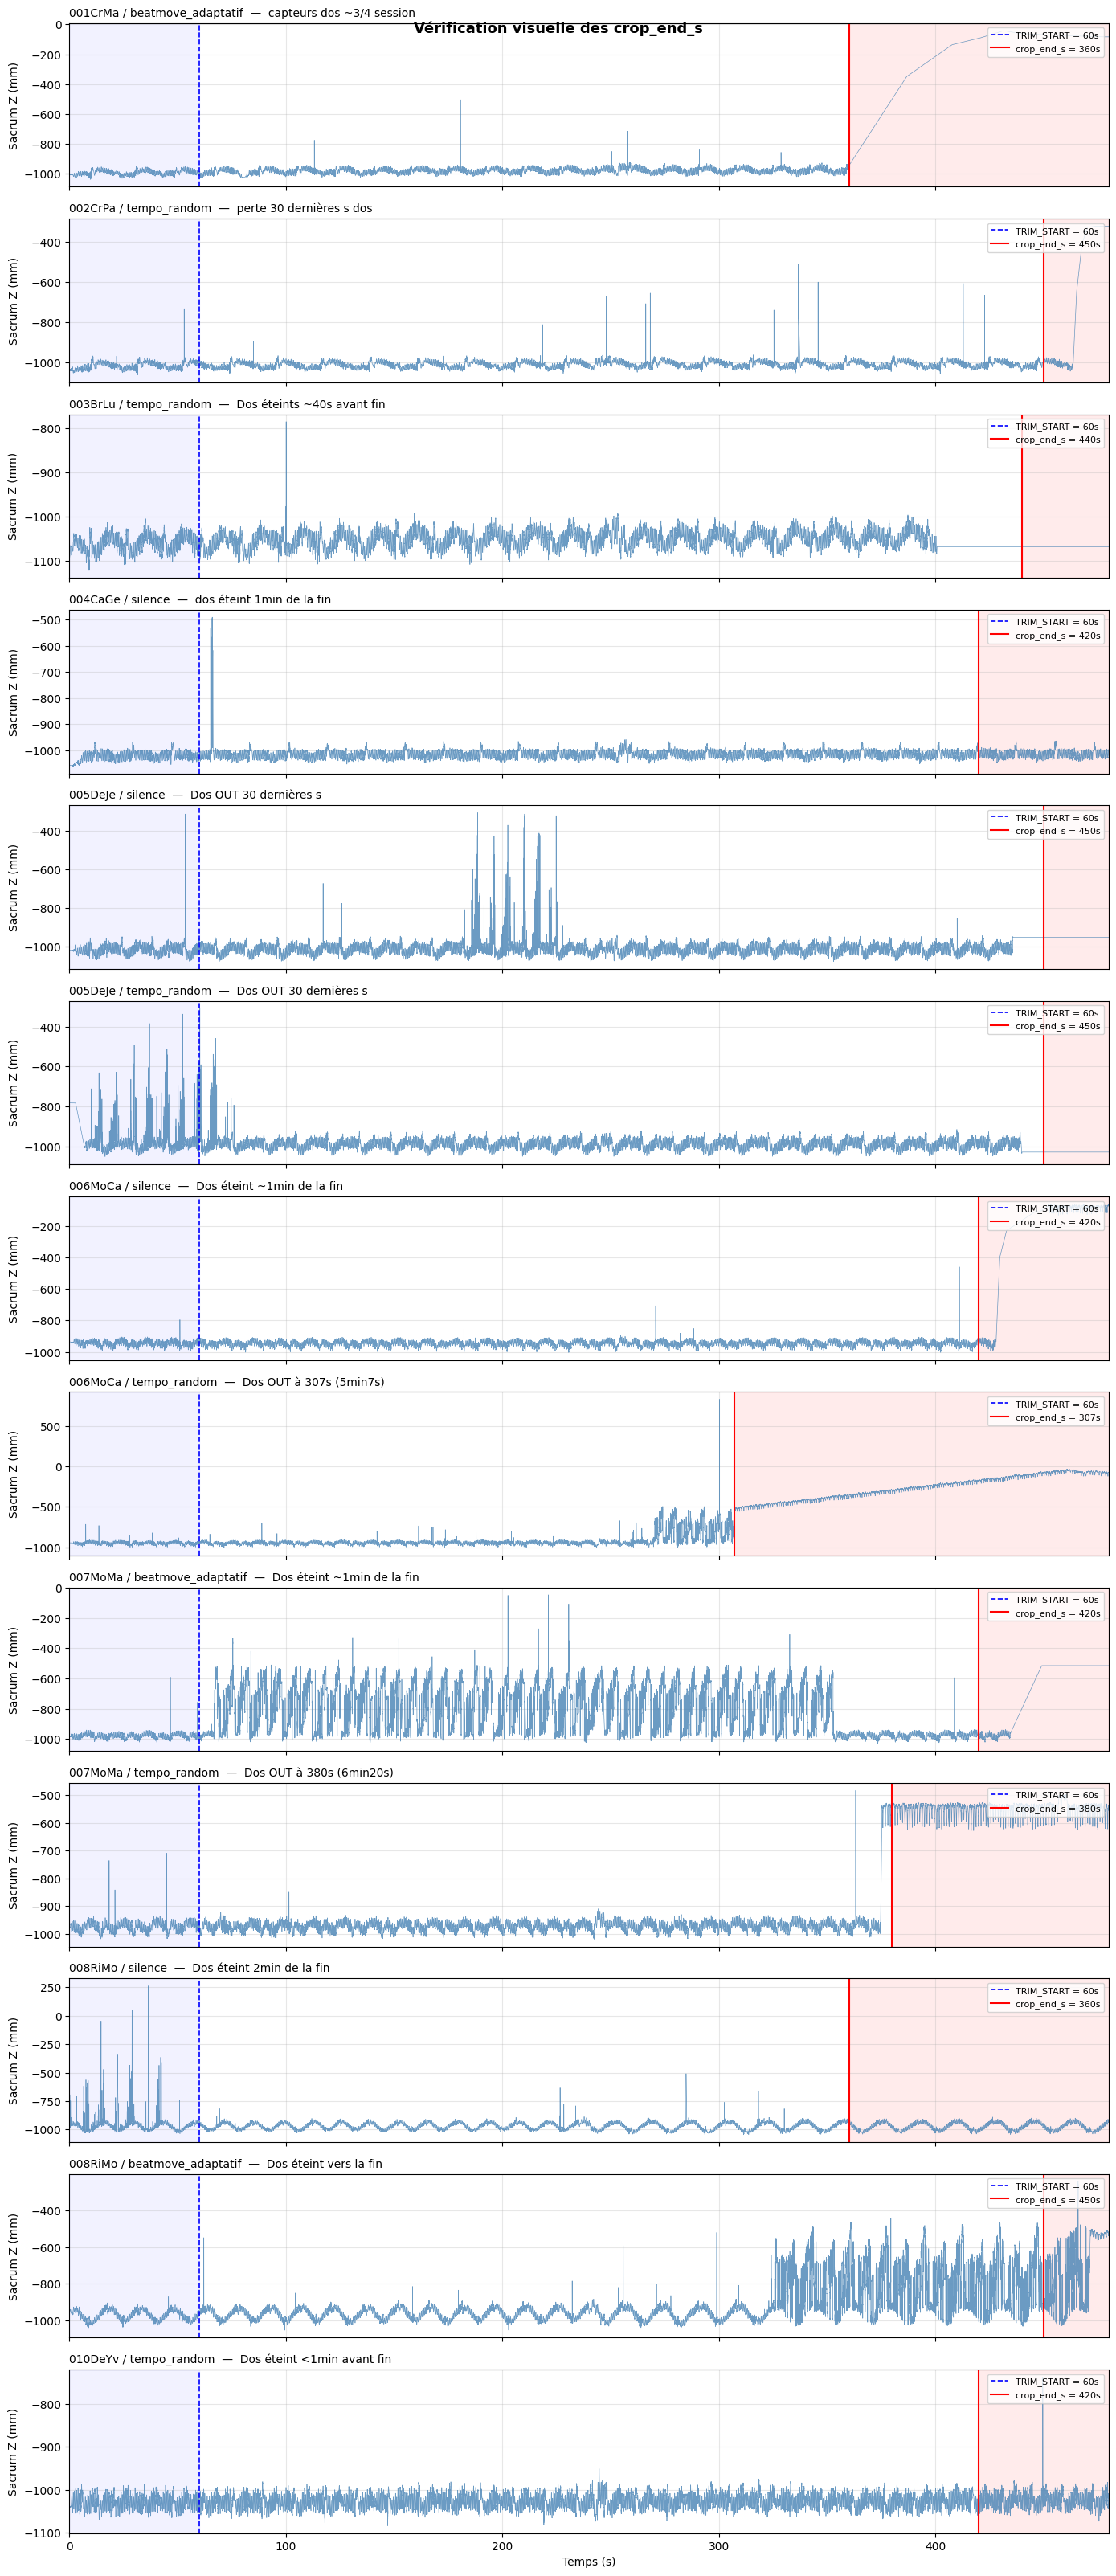

In [3]:
FS = config.FS_RAW       # 400 Hz
SESSION_DURATION = config.SESSION_DURATION_S  # 480 s
TRIM_START = config.TRIM_START_S              # 60 s

n_plots = len(CROPS_TO_CHECK)
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 2.5 * n_plots), sharex=True)
if n_plots == 1:
    axes = [axes]

for ax, (participant, condition, crop_s, raison) in zip(axes, CROPS_TO_CHECK):
    try:
        # 1. Charger .mat et extraire trajectoires
        raw_path = paths.raw_file(participant, condition)
        data, fmt = loader.load_mat(raw_path)
        trajectories = loader.extract_marker_trajectories(data, fmt)
        
        # 2. Barycentre dos (sans centrage : on veut voir l'allure absolue Z)
        bary = compute_barycenter(trajectories, center_on_mean=False)
        sacrum_z = bary[:, 2]   # axe Z
        t = np.arange(len(sacrum_z)) / FS
        
        # 3. Plot
        ax.plot(t, sacrum_z, color='steelblue', linewidth=0.5, alpha=0.8)
        ax.axvline(TRIM_START, color='blue', linestyle='--', linewidth=1.2,
                   label=f'TRIM_START = {TRIM_START}s')
        ax.axvline(crop_s, color='red', linewidth=1.5,
                   label=f'crop_end_s = {crop_s}s')
        
        # Zone après crop en rouge clair
        ax.axvspan(crop_s, SESSION_DURATION, color='red', alpha=0.08)
        # Zone avant TRIM_START en bleu clair
        ax.axvspan(0, TRIM_START, color='blue', alpha=0.05)
        
        ax.set_title(f"{participant} / {condition}  —  {raison}", fontsize=10, loc='left')
        ax.set_ylabel('Sacrum Z (mm)')
        ax.legend(loc='upper right', fontsize=8)
        ax.set_xlim(0, SESSION_DURATION)
        ax.grid(alpha=0.3)
        
    except Exception as e:
        ax.text(0.5, 0.5, f'❌ Erreur : {e}', ha='center', va='center',
                transform=ax.transAxes, color='red')
        ax.set_title(f"{participant} / {condition}  —  ÉCHEC", fontsize=10, loc='left')

axes[-1].set_xlabel('Temps (s)')
plt.suptitle('Vérification visuelle des crop_end_s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Marche à suivre après visualisation

Pour chaque essai ci-dessus, valide ou ajuste la valeur en regardant :

1. **Signal aberrant (plat, sauts brutaux, valeurs constantes)** → le crop doit être à ce moment
2. **Signal encore propre après la ligne rouge** → on peut descendre le crop (récupérer plus de données)
3. **Signal déjà aberrant avant la ligne rouge** → il faut remonter le crop

Une fois validé, mets les valeurs définitives dans `src/resilience/participants.py`
en remplissant `crop_end_s` pour chaque essai concerné.

## (Optionnel) Zoom sur un essai unique pour décision fine

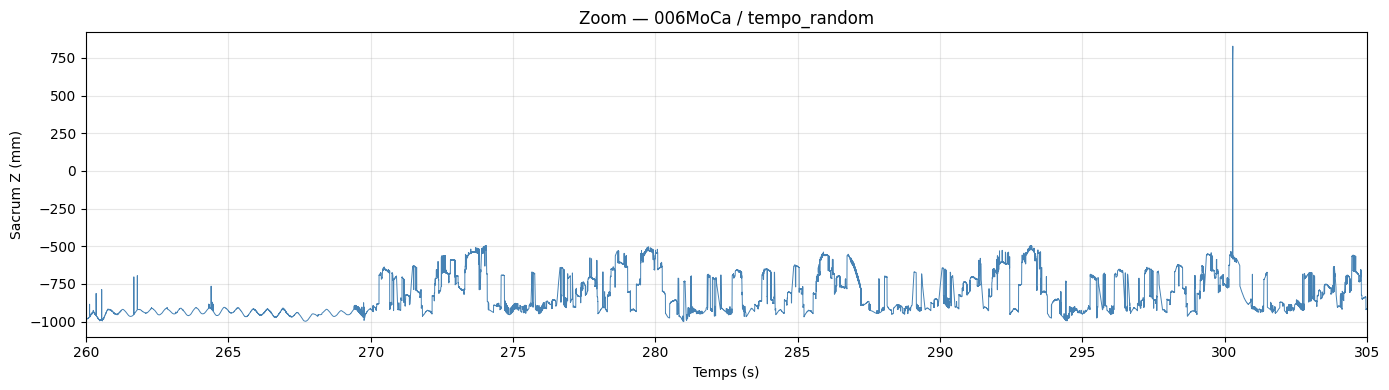

In [55]:
# Modifie ces valeurs pour zoomer sur un essai problématique
ZOOM_PARTICIPANT = '006MoCa'
ZOOM_CONDITION   = 'tempo_random'
ZOOM_T_START_S   = 260
ZOOM_T_END_S     = 305

raw_path = paths.raw_file(ZOOM_PARTICIPANT, ZOOM_CONDITION)
data, fmt = loader.load_mat(raw_path)
trajectories = loader.extract_marker_trajectories(data, fmt)
bary = compute_barycenter(trajectories, center_on_mean=False)
sacrum_z = bary[:, 2]
t = np.arange(len(sacrum_z)) / FS

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, sacrum_z, color='steelblue', linewidth=0.7)
ax.set_xlim(ZOOM_T_START_S, ZOOM_T_END_S)
ax.set_title(f'Zoom — {ZOOM_PARTICIPANT} / {ZOOM_CONDITION}')
ax.set_xlabel('Temps (s)')
ax.set_ylabel('Sacrum Z (mm)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Total essais à tracer : 42


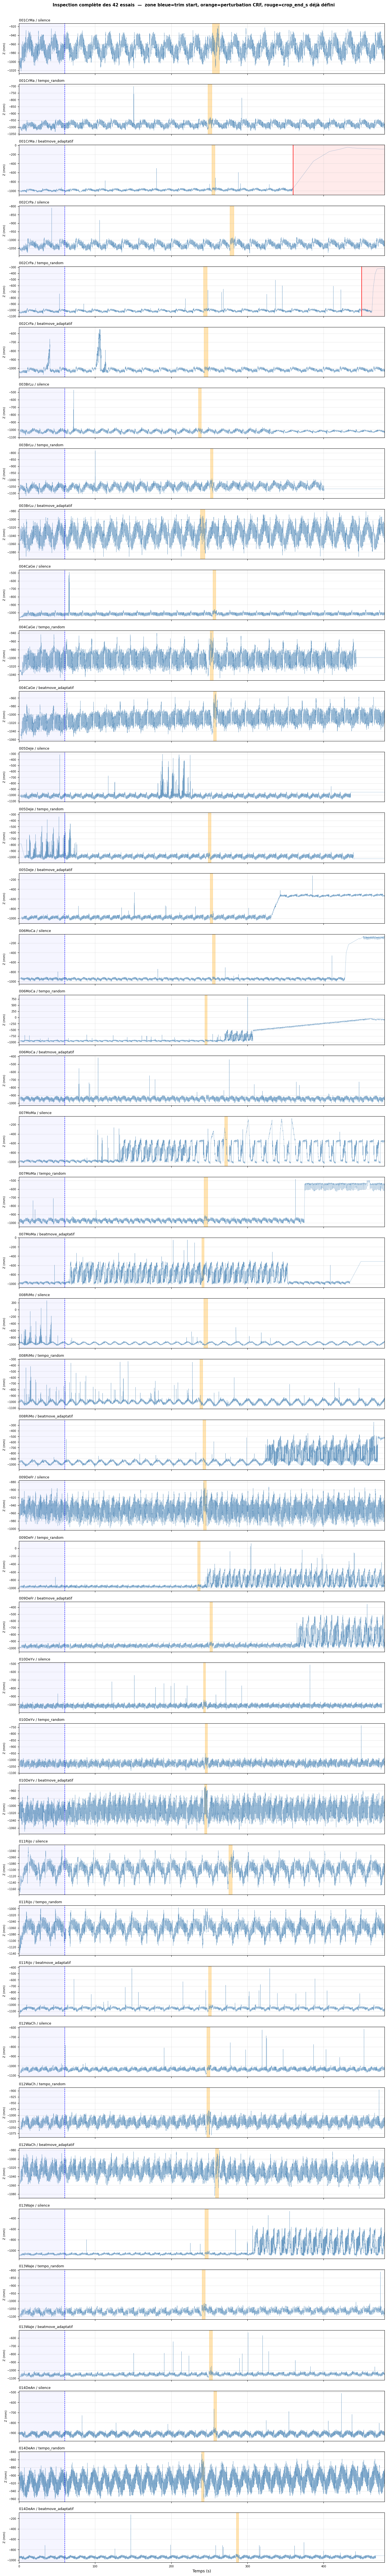


→ Image sauvée : inspection_42_essais.png


In [5]:
# ════════════════════════════════════════════════════════════════════
# INSPECTION COMPLÈTE : TOUS les essais (14 × 3 = 42)
# ════════════════════════════════════════════════════════════════════
# Trace le sacrum Z brut pour CHAQUE essai disponible.
# But : repérer visuellement les zones aberrantes (artefacts, capteurs out)
# Puis remplir le document crop_decisions.txt avec tes annotations.

import warnings
warnings.filterwarnings('ignore')

ALL_PARTICIPANTS = participants.list_codes()
ALL_CONDITIONS   = ['silence', 'tempo_random', 'beatmove_adaptatif']

trials_to_plot = [(p, c) for p in ALL_PARTICIPANTS for c in ALL_CONDITIONS]
print(f"Total essais à tracer : {len(trials_to_plot)}")

n_plots = len(trials_to_plot)
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 2.2 * n_plots), sharex=True)

for ax, (participant, condition) in zip(axes, trials_to_plot):
    try:
        raw_path = paths.raw_file(participant, condition)
        data, fmt = loader.load_mat(raw_path)
        trajectories = loader.extract_marker_trajectories(data, fmt)
        bary = compute_barycenter(trajectories, center_on_mean=False)
        sacrum_z = bary[:, 2]
        t = np.arange(len(sacrum_z)) / FS

        ax.plot(t, sacrum_z, color='steelblue', linewidth=0.4, alpha=0.8)
        ax.axvline(TRIM_START, color='blue', linestyle='--', linewidth=1)
        ax.axvspan(0, TRIM_START, color='blue', alpha=0.04)

        # Marquer la perturbation CRF si disponible
        trial = participants.get_trial(participant, condition)
        if trial.crf_entry_s is not None:
            ax.axvspan(trial.crf_entry_s, trial.crf_exit_s, color='orange', alpha=0.3)

        # Marquer crop_end_s si déjà défini
        if trial.crop_end_s is not None:
            ax.axvline(trial.crop_end_s, color='red', linewidth=1.3)
            ax.axvspan(trial.crop_end_s, SESSION_DURATION, color='red', alpha=0.08)

        ax.set_title(f"{participant} / {condition}", fontsize=9, loc='left')
        ax.set_ylabel('Z (mm)', fontsize=8)
        ax.set_xlim(0, SESSION_DURATION)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f'❌ .mat introuvable', ha='center', va='center',
                transform=ax.transAxes, color='gray', fontsize=10)
        ax.set_title(f"{participant} / {condition}", fontsize=9, loc='left')
    except Exception as e:
        ax.text(0.5, 0.5, f'❌ {type(e).__name__}', ha='center', va='center',
                transform=ax.transAxes, color='red', fontsize=10)

axes[-1].set_xlabel('Temps (s)')
plt.suptitle('Inspection complète des 42 essais  —  zone bleue=trim start, orange=perturbation CRF, rouge=crop_end_s déjà défini',
             fontsize=11, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('inspection_42_essais.png', dpi=80, bbox_inches='tight')
plt.show()
print("\n→ Image sauvée : inspection_42_essais.png")

In [6]:
# ════════════════════════════════════════════════════════════════════
# INSPECTION PAR PARTICIPANT : 1 image = 3 essais (silence + tempo + beatmove)
# ════════════════════════════════════════════════════════════════════
# Exporte 14 PNG distincts dans inspection_par_participant/
# Plus facile à inspecter visuellement et à transmettre.

import warnings
import os
warnings.filterwarnings('ignore')

OUTPUT_DIR = 'inspection_par_participant'
os.makedirs(OUTPUT_DIR, exist_ok=True)

ALL_PARTICIPANTS = participants.list_codes()
ALL_CONDITIONS   = ['silence', 'tempo_random', 'beatmove_adaptatif']

print(f"Export de {len(ALL_PARTICIPANTS)} images dans ./{OUTPUT_DIR}/\n")

for participant in ALL_PARTICIPANTS:
    fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

    for ax, condition in zip(axes, ALL_CONDITIONS):
        try:
            raw_path = paths.raw_file(participant, condition)
            data, fmt = loader.load_mat(raw_path)
            trajectories = loader.extract_marker_trajectories(data, fmt)
            bary = compute_barycenter(trajectories, center_on_mean=False)
            sacrum_z = bary[:, 2]
            t = np.arange(len(sacrum_z)) / FS

            ax.plot(t, sacrum_z, color='steelblue', linewidth=0.5, alpha=0.85)
            ax.axvline(TRIM_START, color='blue', linestyle='--', linewidth=1)
            ax.axvspan(0, TRIM_START, color='blue', alpha=0.05)

            trial = participants.get_trial(participant, condition)
            if trial.crf_entry_s is not None:
                ax.axvspan(trial.crf_entry_s, trial.crf_exit_s, color='orange', alpha=0.3)

            if trial.crop_end_s is not None:
                ax.axvline(trial.crop_end_s, color='red', linewidth=1.3)
                ax.axvspan(trial.crop_end_s, SESSION_DURATION, color='red', alpha=0.1)

            ax.set_title(f"{condition}", fontsize=10, loc='left', fontweight='bold')
            ax.set_ylabel('Z (mm)', fontsize=9)
            ax.set_xlim(0, SESSION_DURATION)
            ax.grid(alpha=0.3)
            ax.tick_params(labelsize=8)
        except FileNotFoundError:
            ax.text(0.5, 0.5, '❌ .mat introuvable', ha='center', va='center',
                    transform=ax.transAxes, color='gray', fontsize=11)
            ax.set_title(f"{condition}", fontsize=10, loc='left', fontweight='bold')
        except Exception as e:
            ax.text(0.5, 0.5, f'❌ {type(e).__name__}: {e}', ha='center', va='center',
                    transform=ax.transAxes, color='red', fontsize=9)
            ax.set_title(f"{condition}", fontsize=10, loc='left', fontweight='bold')

    axes[-1].set_xlabel('Temps (s)', fontsize=10)
    plt.suptitle(f'{participant}  —  bleu=trim start, orange=perturbation CRF, rouge=crop_end_s',
                 fontsize=12, fontweight='bold', y=1.00)
    plt.tight_layout()

    out_path = os.path.join(OUTPUT_DIR, f'{participant}.png')
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.close(fig)
    print(f"  ✅ {out_path}")

print(f"\n→ {len(ALL_PARTICIPANTS)} images exportées dans ./{OUTPUT_DIR}/")

Export de 14 images dans ./inspection_par_participant/

  ✅ inspection_par_participant\001CrMa.png
  ✅ inspection_par_participant\002CrPa.png
  ✅ inspection_par_participant\003BrLu.png
  ✅ inspection_par_participant\004CaGe.png
  ✅ inspection_par_participant\005DeJe.png
  ✅ inspection_par_participant\006MoCa.png
  ✅ inspection_par_participant\007MoMa.png
  ✅ inspection_par_participant\008RiMo.png
  ✅ inspection_par_participant\009DeFr.png
  ✅ inspection_par_participant\010DeYv.png
  ✅ inspection_par_participant\011RiJo.png
  ✅ inspection_par_participant\012WaCh.png
  ✅ inspection_par_participant\013WaJe.png
  ✅ inspection_par_participant\014DeAn.png

→ 14 images exportées dans ./inspection_par_participant/
